In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
# read csv file
df = pd.read_csv('worldometer_coronavirus_daily_data.csv')
df.head()

,date,country,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths
0,2020-2-15,Afghanistan,0.0,NaN,0.0,0.0,NaN
1,2020-2-16,Afghanistan,0.0,NaN,0.0,0.0,NaN
2,2020-2-17,Afghanistan,0.0,NaN,0.0,0.0,NaN
3,2020-2-18,Afghanistan,0.0,NaN,0.0,0.0,NaN
4,2020-2-19,Afghanistan,0.0,NaN,0.0,0.0,NaN


In [6]:
# check for missing data
df.isnull().sum()

,0
date,0
country,0
cumulative_total_cases,0
daily_new_cases,10458
active_cases,18040
cumulative_total_deaths,6560
daily_new_deaths,26937


In [7]:
# filling missing value
df.fillna(0, inplace = True)

In [8]:
# data conversion
df['Date'] = pd.to_datetime(df['date'])

In [10]:
# EDA
df.describe(include = 'all')

,date,country,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths,Date
count,184787,184787,1.847870e+05,184787.000000,1.847870e+05,1.847870e+05,184787.000000,184787
unique,844,226,NaN,NaN,NaN,NaN,NaN,NaN
top,2022-4-09,China,NaN,NaN,NaN,NaN,NaN,NaN
freq,226,844,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,7.251089e+05,2818.548507,5.630167e+04,1.339304e+04,34.025418,2021-03-30 20:11:51.556549120
min,NaN,NaN,0.000000e+00,-322.000000,-1.432100e+04,0.000000e+00,-39.000000,2020-01-22 00:00:00
25%,NaN,NaN,1.099000e+03,0.000000,9.000000e+00,1.200000e+01,0.000000,2020-09-07 00:00:00
50%,NaN,NaN,1.775600e+04,41.000000,8.110000e+02,2.580000e+02,0.000000,2021-03-31 00:00:00
75%,NaN,NaN,2.238085e+05,636.000000,1.147900e+04,3.696000e+03,8.000000,2021-10-22 00:00:00
max,NaN,NaN,8.420947e+07,909610.000000,1.793543e+07,1.026646e+06,5093.000000,2022-05-14 00:00:00


In [11]:
df['country'].value_counts().head(10)

,count
country,
China,844
Afghanistan,820
Algeria,820
Andorra,820
Angola,820
Anguilla,820
Antigua And Barbuda,820
Argentina,820
Armenia,820


In [13]:
# groupby
top_country = df[df['date'] == '2021-12-31'].groupby('country')['active_cases'].sum().nlargest(5) # top 5 largest values
top_country

,active_cases
country,
USA,5898982.0
UK,3211277.0
France,1757767.0
Spain,1234014.0
Viet Nam,1221390.0


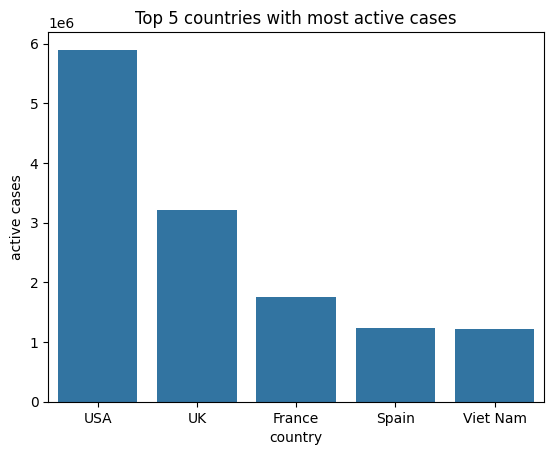

In [14]:
sns.barplot(top_country)
plt.ylabel('active cases')
plt.xlabel('country')
plt.title('Top 5 countries with most active cases')
plt.show()

# Khi bạn truyền trực tiếp Series vào sns.barplot():
# Index → sẽ làm trục x (country)
# Value → sẽ làm trục y (active_case)
# Cách chuẩn & an toàn hơn là: sns.barplot(x=top_country.index, y=top_country.values)

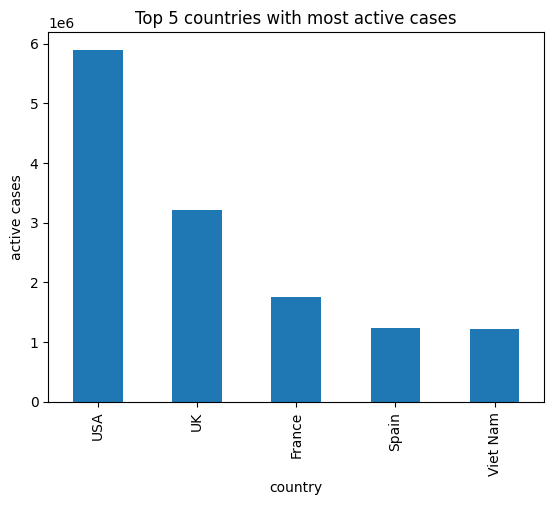

In [15]:
# cách vẽ khác
top_country.plot(kind = 'bar', title = 'Top 5 countries with most active cases')
plt.ylabel('active cases')
plt.show()

In [22]:
df['death_rate'] = df['cumulative_total_deaths'] / df['active_cases']

highest_death_rate = df.groupby('country')['cumulative_total_deaths'].mean().nlargest(5).sort_values(ascending = False)
highest_death_rate.head()

,cumulative_total_deaths
country,
USA,502389.824390
Brazil,345425.790244
India,256603.291463
Mexico,180876.767073
Russia,133342.856098


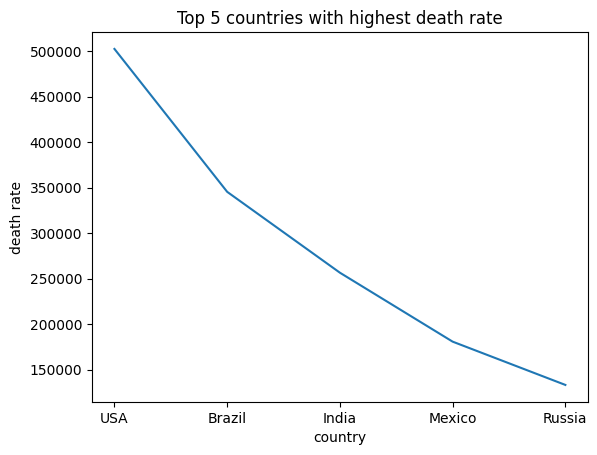

In [23]:
sns.lineplot(x = highest_death_rate.index, y = highest_death_rate.values)
plt.title('Top 5 countries with highest death rate')
plt.xlabel('country')
plt.ylabel('death rate')
plt.show()